In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Transformatino on dataset
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32,padding=4),
    transforms.ColorJitter(
        brightness =0.1,
        contrast=0.1,
        saturation=0.1
    ),
     transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )

])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Load CIFAR10 Dataset form torchvision library
train_dataset = torchvision.datasets.CIFAR10(
   root='./data',
   train=True,
   download=True,
   transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 170M/170M [00:01<00:00, 99.9MB/s] 


In [4]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False, pin_memory=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.65618].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5781386].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6366696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.4559333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.402546].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.390296..2.262084].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.

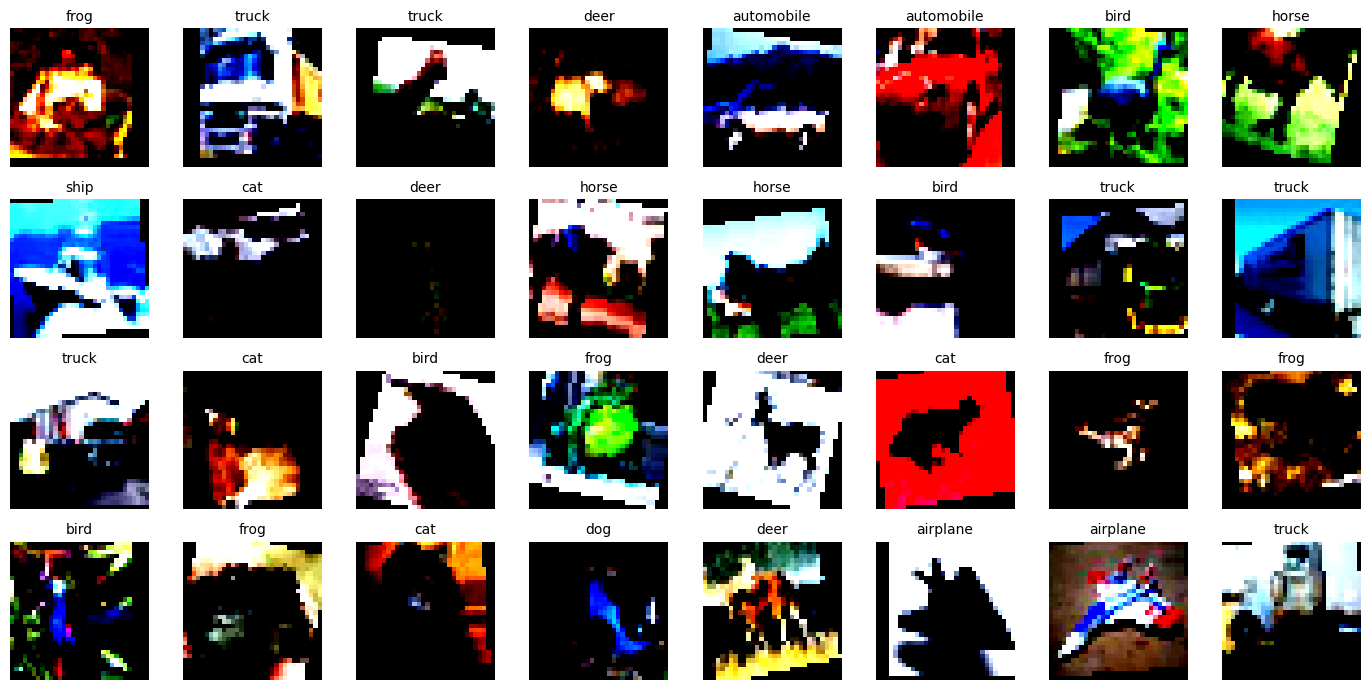

In [5]:
# Visualize dataset

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(4, 8, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [6]:
class ResidualBlock(nn.Module):

    def __init__(self,in_channel,out_channel,stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channel,out_channel,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.conv2 = nn.Conv2d(out_channel,out_channel,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channel)

        self.shortcut = nn.Sequential()
        if stride !=1 or in_channel != out_channel:
          self.shortcut = nn.Sequential(
              nn.Conv2d(in_channel,out_channel,kernel_size=1,stride=stride,bias=False),
              nn.BatchNorm2d(out_channel)
          )

    def forward(self,x):
      out = F.relu(self.bn1(self.conv1(x)))
      out = self.bn2(self.conv2(out))
      out += self.shortcut(x)
      out = F.relu(out)
      return out


In [7]:
# making CNN class

class MyCNN(nn.Module):

  def __init__(self,num_channels):
    super().__init__()

    self.conv1 = nn.Sequential(
        nn.Conv2d(num_channels,32,kernel_size=3,stride=1,padding=1,bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(),
    )

    self.layer1 = ResidualBlock(32,32)
    self.layer2 = ResidualBlock(32,64,stride=2)
    self.layer3 = ResidualBlock(64,64)
    self.layer4 = ResidualBlock(64,128,stride=2)



    self.classifier = nn.Sequential(
       nn.AdaptiveAvgPool2d((1,1)),
       nn.Flatten(),
       nn.Linear(128,10),
    )

  def forward(self,x):
    x = self.conv1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.classifier(x)

    return(x)

In [8]:
# define some parameters
learning_rate = 0.001
epochs = 100

In [9]:
# intialize model
model  = MyCNN(3)
model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=0.001)


In [10]:
for i in range(epochs):
  total_loss = 0
  for batch_features,batch_labels in train_loader:

    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update parameters
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch : {i+1} ,Total Loss : {total_loss/len(train_loader)}")

Epoch : 1 ,Total Loss : 1.4731879014276346
Epoch : 2 ,Total Loss : 1.1379634688011897
Epoch : 3 ,Total Loss : 1.0029622219879506
Epoch : 4 ,Total Loss : 0.903377756581273
Epoch : 5 ,Total Loss : 0.8387814793576053
Epoch : 6 ,Total Loss : 0.802515840862168
Epoch : 7 ,Total Loss : 0.765144355962159
Epoch : 8 ,Total Loss : 0.7447438991687577
Epoch : 9 ,Total Loss : 0.728187752700508
Epoch : 10 ,Total Loss : 0.7122918765894206
Epoch : 11 ,Total Loss : 0.7005443502067376
Epoch : 12 ,Total Loss : 0.69545246455735
Epoch : 13 ,Total Loss : 0.6827040786496813
Epoch : 14 ,Total Loss : 0.6687487595674706
Epoch : 15 ,Total Loss : 0.6662273601851094
Epoch : 16 ,Total Loss : 0.6548046411342218
Epoch : 17 ,Total Loss : 0.6542632915580112
Epoch : 18 ,Total Loss : 0.6480761516364965
Epoch : 19 ,Total Loss : 0.6463240911124688
Epoch : 20 ,Total Loss : 0.6373281265327126
Epoch : 21 ,Total Loss : 0.6385135644819213
Epoch : 22 ,Total Loss : 0.6362603905104859
Epoch : 23 ,Total Loss : 0.6329298370058386
Epo

In [11]:
total = 0
correct = 0

with torch.no_grad():
    for batch_feature,batch_labels in test_loader:
        batch_feature,batch_labels = batch_feature.to(device),batch_labels.to(device)
        output = model(batch_feature)
        _,predict = torch.max(output,1)
        total += batch_labels.shape[0]
        correct += (predict == batch_labels).sum().item()
    print(f"Accuracy: {correct/total}")

Accuracy: 0.7452


In [12]:
total = 0
correct = 0

with torch.no_grad():
    for batch_feature,batch_labels in train_loader:
        batch_feature,batch_labels = batch_feature.to(device),batch_labels.to(device)
        output = model(batch_feature)
        _,predict = torch.max(output,1)
        total += batch_labels.shape[0]
        correct += (predict == batch_labels).sum().item()
    print(f"Accuracy: {correct/total}")

Accuracy: 0.81124
